In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.stats as stats

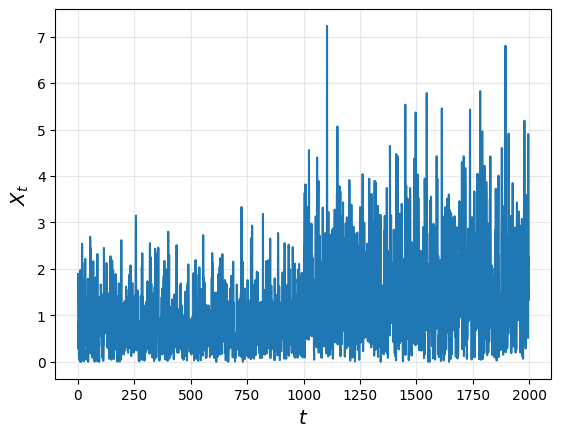

In [12]:
# 生成一组随机数据

N = 1000
σ1 = 1.0
σ2 = 2.0

X = np.random.randn(2 * N)
X[:N] *= σ1
X[N:] *= σ2
X = np.abs(X)

plt.plot(X)
plt.xlabel("$t$",   size=14)
plt.ylabel("$X_t$", size=14)
plt.grid(alpha=0.3)
plt.show()

+ 如果 $X_t$ 来自于同一个正态分布（取绝对值前），定义

  $$
  F_i = \frac{\sum_{t=(i+1)T}^{(i+2)T-1}X_t^2}{\sum_{t=iT}^{(i+1)T-1}X_t^2},
  $$

  其中 $T$ 是每个不重叠切片的大小，则 $F_i$ 服从自由度为 $(T, T)$ 的 F 分布


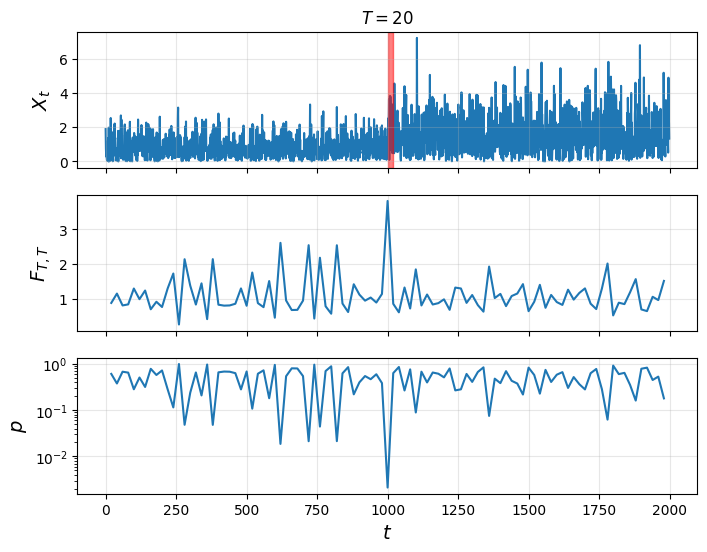

In [59]:
# 不重叠切片大小
T = 20

# 计算 F 统计量
F = np.zeros(2 * N // T - 1)
for i,_ in enumerate(F):
    F[i] = np.mean(X[T*(i+1):T*(i+2)]**2) / np.mean(X[T*i:T*(i+1)]**2)

# 计算 P 值
P = stats.f(T, T).sf(F)

# 可视化结果
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax = axes[0]
line,  = ax.plot(X)
line.zorder = -1
ymin, ymax = ax.get_ylim()
for i, p in enumerate(P):
    if p < threshold:
        ax.fill_between([T*(i+1), T*(i+2)], ymin, ymax, color="r", alpha=0.5)
ax.set_ylim(ymin, ymax)
ax.set_ylabel("$X_t$", size=14)
ax.set_title(f"$T = {T}$")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.arange(len(F)) * T + T, F)
ax.set_ylabel(r"$F_{T, T}$", size=14)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(np.arange(len(P)) * T + T, P)
ax.set_xlabel("$t$",   size=14)
ax.set_ylabel("$p$", size=14)
ax.semilogy()
ax.grid(alpha=0.3)


plt.show()

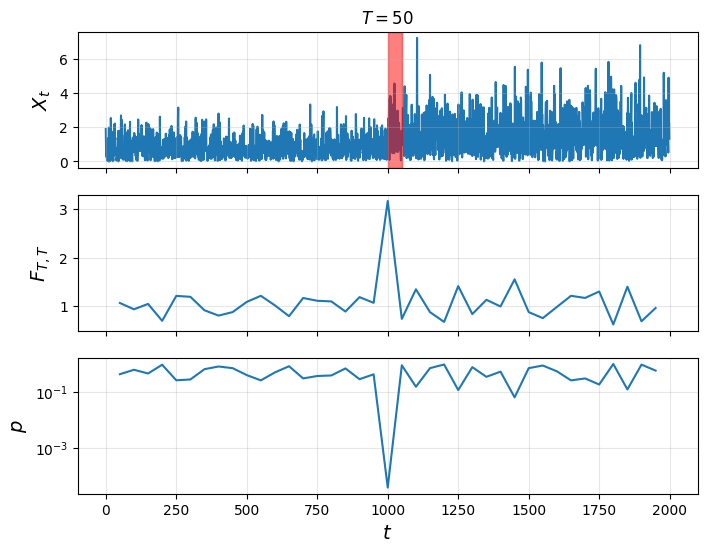

In [58]:
# 更大的不重叠切片
T = 50

# 计算 F 统计量
F = np.zeros(2 * N // T - 1)
for i,_ in enumerate(F):
    F[i] = np.mean(X[T*(i+1):T*(i+2)]**2) / np.mean(X[T*i:T*(i+1)]**2)

# 计算 P 值
P = stats.f(T, T).sf(F)

# 可视化结果
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax = axes[0]
line,  = ax.plot(X)
line.zorder = -1
ymin, ymax = ax.get_ylim()
for i, p in enumerate(P):
    if p < threshold:
        ax.fill_between([T*(i+1), T*(i+2)], ymin, ymax, color="r", alpha=0.5)
ax.set_ylim(ymin, ymax)
ax.set_ylabel("$X_t$", size=14)
ax.set_title(f"$T = {T}$")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.arange(len(F)) * T + T, F)
ax.set_ylabel(r"$F_{T, T}$", size=14)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(np.arange(len(P)) * T + T, P)
ax.set_xlabel("$t$",   size=14)
ax.set_ylabel("$p$", size=14)
ax.semilogy()
ax.grid(alpha=0.3)

plt.show()